# The 1929 Overlay — a quantitative teardown 🔬
### Analogue forecasting · spurious path correlation · 126 combinations, corrected

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Shape check: Confirmed](https://img.shields.io/badge/Shape_check-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The study
generalises the viral overlay chart into a k-nearest-analogue forecaster, scores it out of sample
on two real tapes with overlap-robust inference, reports the whole parameter grid with Holm and
Reality-Check corrections, and calibrates the famous-looking matches against random walks — plain,
volatility-path-matched and block-bootstrapped.

> ⚠️ **Not investment advice.** Tapes: Fama-French US market **monthly total return**
> (1926-07 → 2018-11, from `arch`) and S&P 500 **daily price index** (1990-01 → 2022-11, from
> `skfolio`), both via `quantlab.bundled`, SHA-256 pinned. Headline numbers mirror
> [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from overlay import data, strategy as st
RED, GREY, BLUE, GREEN, AMBER = "#c0392b", "#8b949e", "#1f6feb", "#2ea44f", "#dab617"

In [2]:
m = data.load_monthly()   # REAL: monthly TOTAL return, nominal, with T-bill rf
d = data.load_daily()     # REAL: daily PRICE index, nominal, rf = 0 (none ships)
mm, dm = data.tape_moments(m["lr"], 12), data.tape_moments(d["lr"], 252)
print(f"monthly {m.index[0].date()}..{m.index[-1].date()}  n={len(m)}  fp {data.fingerprint(m[['ret','rf']])}"
      f"  drift {mm['mu_ann']:.2%}/yr vol {mm['sigma_ann']:.2%}/yr")
print(f"daily   {d.index[0].date()}..{d.index[-1].date()}  n={len(d)}  fp {data.fingerprint(d[['px']])}"
      f"  drift {dm['mu_ann']:.2%}/yr vol {dm['sigma_ann']:.2%}/yr")

monthly 1926-07-31..2018-11-30  n=1109  fp c7f1e4140bfb  drift 9.48%/yr vol 18.40%/yr
daily   1990-01-02..2022-11-30  n=8294  fp e223c581ae22  drift 7.38%/yr vol 18.32%/yr


## Verdict, up front

**Signal: None.** The pre-registered monthly forecaster (24-month match, 5
analogues, 12-month forecast, 1950-2018 out of sample) has a Newey-West t of **+1.77**
and an out-of-sample R² of −21.6% against the plain historical drift; the daily S&P 500
version gives t **−1.63**. Across all **126 combinations** tried,
5 (4%) were raw-significant — chance gives 5% — and the
best Holm-adjusted p is **1.00**. The one number that survives a two-sided
correction points the *wrong* way (daily price path, L=63, h=63, k=5, t −4.31).

**Tradability: Mirage.** Going to cash when the analogues forecast a loss (one period
of lag, 10 bp one-way): net excess Sharpe **0.47 vs 0.52** for
buy-and-hold monthly, **0.22 vs 0.34** daily; White's Reality Check over
every rule, p = 1.00 and 1.00.

**Shape check: Confirmed.** Real history matches itself a shade better than a random walk
(median best match 0.946 vs 0.903), mostly because of volatility
clustering (0.919 with the real volatility path, 0.931 for a
6-month block bootstrap). The shapes rhyme; what follows them does not.

> 💡 **In plain words.** Look-alike charts are cheap, and what followed the look-alikes tells
> you nothing about what follows today.

## 1 · Hypotheses (pre-registered)

- **H₁ (skill).** The analogue forecast's slope on the realised h-period return is positive:
  Newey-West t ≥ 2 on the headline spec of **both** tapes (monthly L=24 m, h=12 m, k=5; daily
  L=250 d, h=63 d, k=5; price-path matching), and the best combination survives Holm across the
  whole grid.
- **H₂ (tradability).** A long/flat rule (one period of execution lag, 10 bp one-way) beats
  buy-and-hold on net excess Sharpe on both tapes, and White's Reality Check rejects.
- **H₃ (spurious matching).** The real tape's best-match correlations are no higher than those of
  random walks with the same drift and vol, searched identically.
- **H₄ (power).** On a synthetic tape with a genuinely recurring template, the same test rejects;
  on the matched null it rejects at about its nominal rate.

The stamps follow `strategy.verdict` / `strategy.myth_check`, thresholds fixed before the real
run and unit-tested in both directions.

## 2 · The machinery

At each evaluation date `t`: z-normalise the last `L` points (log-price path, or L log returns
for `zret`), dot it with every past window ending at `e ≤ t − max(L, h)` — a Pearson
correlation — then pick `k` analogues greedily, removing every window within `L` of each pick so
the ten best are not ten one-period shifts of one episode. The forecast is the mean of
`logp[e+h] − logp[e]` over the picks.

In [3]:
idx_m = st.eval_positions(m.index, "1950-01-31")
s = st.analogue_search(m["logp"].to_numpy(), 24, idx_m, k_max=10, gap=24)
t_last = len(idx_m) - 1
ends, cors = s["ends"][t_last], s["corr"][t_last]
print(f"query: the 24 months to {m.index[idx_m[t_last]].date()}")
print(pd.DataFrame({"analogue ends": m.index[ends].date, "corr": cors}).to_string(index=False))
gaps = np.diff(np.sort(ends))
print(f"\nminimum spacing between analogues: {gaps.min()} months (>= L = 24 by construction)")

query: the 24 months to 2018-11-30
analogue ends   corr
   1965-07-31 0.9746
   1959-10-31 0.9742
   1956-06-30 0.9681
   2014-10-31 0.9652
   1951-11-30 0.9642
   1996-08-31 0.9627
   1937-01-31 0.9602
   1928-07-31 0.9543
   1946-08-31 0.9541
   1944-03-31 0.9523

minimum spacing between analogues: 29 months (>= L = 24 by construction)


> 💡 **In plain words.** Ten past look-alikes for November 2018, all above 0.9 — and none of
> them knows anything about December.

## 3 · The spurious-correlation core

### 3.1 One pair: the distribution of corr(price paths) for independent walks, by window

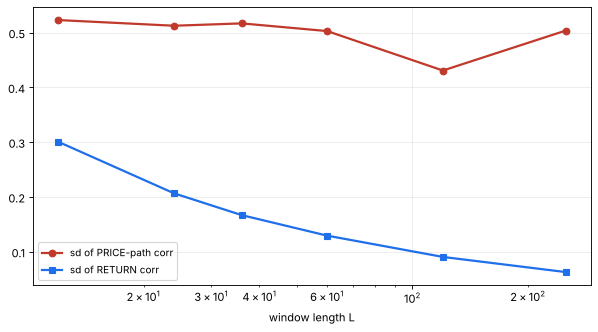

,tape calib,sd(price corr),P(price>0.7),P(price>0.9),sd(return corr),P(ret>0.5)
L,,,,,,
12,monthly,0.5231,0.1477,0.0224,0.3009,0.0473
24,monthly,0.5128,0.1706,0.0245,0.2068,0.0051
36,monthly,0.5170,0.2213,0.0343,0.1670,0.0005
60,monthly,0.5030,0.3165,0.0597,0.1296,0.0000
120,monthly,0.4310,0.5081,0.1417,0.0907,0.0000
250,daily,0.5038,0.1194,0.0100,0.0631,0.0000


In [4]:
rows = []
for L in (12, 24, 36, 60, 120, 250):
    mo = mm if L <= 120 else dm
    p = st.pair_correlation_null(L, mo["mu"], mo["sigma"], n_sims=8000)
    rows.append({"L": L, "tape calib": "monthly" if L <= 120 else "daily",
                 "sd(price corr)": np.std(p["price"]), "P(price>0.7)": p["p_price_gt_07"],
                 "P(price>0.9)": p["p_price_gt_09"], "sd(return corr)": np.std(p["returns"]),
                 "P(ret>0.5)": p["p_returns_gt_05"]})
t3 = pd.DataFrame(rows).set_index("L")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t3.index, t3["sd(price corr)"], "o-", color=RED, lw=2, label="sd of PRICE-path corr")
ax.plot(t3.index, t3["sd(return corr)"], "s-", color=BLUE, lw=2, label="sd of RETURN corr")
ax.set_xscale("log"); ax.set_xlabel("window length L"); ax.legend(fontsize=9); plt.show()
t3

The return correlation shrinks like `1/√L`, as it should. The price-path correlation does
**not**: its spread barely moves with the window length (Phillips 1986 — it converges to a
non-degenerate random variable). Longer overlays are no safer.

### 3.2 The search: best match against breadth of history

In [5]:
rows = []
for n_hist in (120, 300, 600, 1100):
    b = st.best_match_null(n_hist, 24, mm["mu"], mm["sigma"], n_sims=200, seed=n_hist)
    z = st.best_match_null(n_hist, 24, mm["mu"], mm["sigma"], metric="zret", n_sims=200,
                           seed=n_hist)
    rows.append({"months searched": n_hist, "median best (price)": np.median(b),
                 "P(best>0.9)": np.mean(b > 0.9), "median best (zret)": np.median(z)})
pd.DataFrame(rows).set_index("months searched")

,median best (price),P(best>0.9),median best (zret)
months searched,,,
120,0.8253,0.2850,0.4731
300,0.8819,0.4500,0.5515
600,0.8914,0.4800,0.5830
1100,0.8965,0.4800,0.6216


> 💡 **In plain words.** The longer the history you are allowed to rummage through, the better
> the best "match" gets — for a pure random walk. Ninety years of history buys you a 0.9 about
> half the time.

### 3.3 Like for like, with richer nulls

Same dates, same search. Three nulls: a Gaussian walk with the tape's drift and vol; a walk with
the **real volatility path** (direction coin-flipped); a **6-month stationary block bootstrap**
of the real returns (short memory and fat tails kept, recurrence across years destroyed; blocks
much shorter than L so no window can be copied).

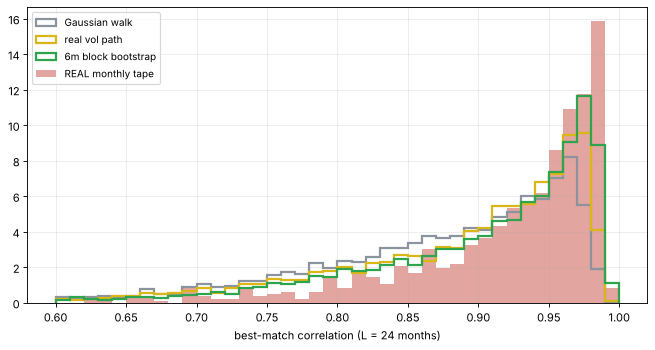

,median,share > 0.9
REAL,0.9462,0.7304
Gaussian walk,0.8942,0.4767
real vol path,0.9158,0.5726
6m block bootstrap,0.9282,0.6212


In [6]:
lp_m = m["logp"].to_numpy()
real = st.analogue_search(lp_m, 24, idx_m, k_max=1)["corr"][:, 0]
nulls = {
    "Gaussian walk": st.null_search_distribution(len(m), 24, mm["mu"], mm["sigma"], idx_m,
                                                 n_sims=8),
    "real vol path": st.null_search_paths(st.vol_path_walks(m["lr"].to_numpy(), 8), 24, idx_m),
    "6m block bootstrap": st.null_search_paths(
        st.block_bootstrap_walks(m["lr"].to_numpy(), 8, mean_block=6.0), 24, idx_m),
}
fig, ax = plt.subplots(figsize=(10, 4.8))
bins = np.linspace(0.6, 1.0, 41)
for (k_, v_), c_ in zip(nulls.items(), (GREY, AMBER, GREEN)):
    ax.hist(v_.ravel(), bins=bins, density=True, histtype="step", lw=2, color=c_, label=k_)
ax.hist(real, bins=bins, density=True, color=RED, alpha=0.45, label="REAL monthly tape")
ax.set_xlabel("best-match correlation (L = 24 months)"); ax.legend(fontsize=9); plt.show()
pd.DataFrame({"median": [np.median(real)] + [np.median(v) for v in nulls.values()],
              "share > 0.9": [np.mean(real > 0.9)] + [np.mean(v > 0.9) for v in nulls.values()]},
             index=["REAL"] + list(nulls))

> 💡 **In plain words.** The real market rhymes with itself a little more than a coin-flip walk,
> and nearly all of that is because turbulent years cluster (a window dominated by one crash or
> one boom looks like a straight line, and straight lines match each other). Put the clustering
> back and the real tape looks like the nulls. The Shape-check stamp is "Confirmed" by its
> pre-registered rule (real beats the *Gaussian* walk), and that is the whole of what it confirms.

### 3.4 The 1929 template — and why it is the trailing rally in disguise

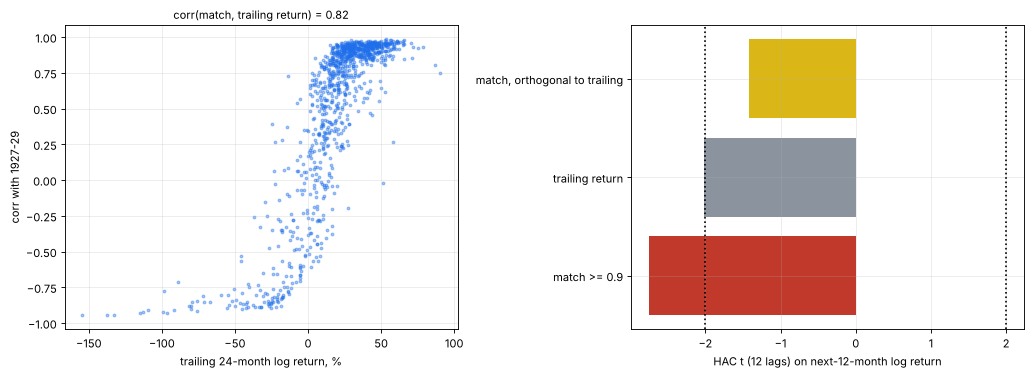

,n_match,share_match,random walk share,fwd_match,fwd_all,diff_t,crash_rate_match,crash_rate_all
threshold,,,,,,,,
0.8000,503,0.4855,0.3409,0.0655,0.1063,-3.1876,0.0497,0.0434
0.9000,301,0.2905,0.1527,0.0574,0.1063,-2.7520,0.0532,0.0434
0.9500,101,0.0975,0.0319,0.0658,0.1063,-1.6374,0.0495,0.0434


In [7]:
ov = st.template_overlay(m["logp"], "1929-08-31", 24, 12).dropna()
trail = (m["logp"] - m["logp"].shift(24)).reindex(ov.index)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(trail * 100, ov["corr"], s=6, alpha=0.4, color=BLUE)
axes[0].set_xlabel("trailing 24-month log return, %"); axes[0].set_ylabel("corr with 1927-29")
axes[0].set_title(f"corr(match, trailing return) = {np.corrcoef(ov['corr'], trail)[0,1]:.2f}",
                  fontsize=10)
ind = (ov["corr"] >= 0.9).to_numpy(float)
res = ind - np.polyval(np.polyfit(trail, ind, 1), trail)
rows = {"match >= 0.9": st.ols_hac(ov["fwd"].to_numpy(), ind, 12)["t_b"],
        "trailing return": st.ols_hac(ov["fwd"].to_numpy(), trail.to_numpy(), 12)["t_b"],
        "match, orthogonal to trailing": st.ols_hac(ov["fwd"].to_numpy(), res, 12)["t_b"]}
axes[1].barh(list(rows), list(rows.values()), color=[RED, GREY, AMBER])
axes[1].axvline(-2, color="k", ls=":"); axes[1].axvline(2, color="k", ls=":")
axes[1].set_xlabel("HAC t (12 lags) on next-12-month log return"); plt.tight_layout(); plt.show()
pos = m.index.get_loc(pd.Timestamp("1929-08-31"))
tn = st.template_null_share(m["logp"].to_numpy()[pos - 23: pos + 1], mm["mu"], mm["sigma"])
pd.DataFrame([{**st.overlay_episodes(ov, th), "random walk share": tn[th]}
              for th in (0.8, 0.9, 0.95)]).set_index("threshold")[
    ["n_match", "share_match", "random walk share", "fwd_match", "fwd_all", "diff_t",
     "crash_rate_match", "crash_rate_all"]]

> 💡 **In plain words.** "Looks like 1929" mostly means "went up a lot for two years". Months
> like that did earn less over the following year — an old, contested long-horizon reversal story
> — but they did not crash more often, and the 1929 *shape* adds little once the size of the rally
> is known.

## 4 · The headline forecasters

In [8]:
idx_d = st.eval_positions(d.index, "2000-01-03", 5)
out = {}
for tag, tape, ix, H, step in (("monthly", m, idx_m, st.HEADLINE_MONTHLY, 1),
                               ("daily", d, idx_d, st.HEADLINE_DAILY, 5)):
    lp = tape["logp"].to_numpy()
    s_ = st.analogue_search(lp, H["L"], ix, k_max=H["k"], gap=max(H["L"], H["h"]))
    fc = st.analogue_forecast(lp, s_, H["h"], H["k"])
    y = st.realised_forward(lp, ix, H["h"]); b = st.historical_drift_forecast(lp, ix, H["h"])
    base = int(np.ceil(H["h"] / step))
    row = st.evaluate_forecast(fc, y, b, base)
    row.update({f"t ({mult}x lags)": st.evaluate_forecast(fc, y, b, base * mult)["t"]
                for mult in (2, 4)})
    row["corr 95% CI"] = st.stationary_bootstrap_corr(fc, y, 300, 2 * base)
    out[tag] = row
    out[tag + "_series"] = (tape.index[ix], fc, y)
pd.DataFrame({k: v for k, v in out.items() if not k.endswith("_series")}).T[
    ["n", "corr", "corr 95% CI", "slope", "t", "t (2x lags)", "t (4x lags)", "hit", "hit_t",
     "hit_raw", "up_share", "oos_r2"]]

,n,corr,corr 95% CI,slope,t,t (2x lags),t (4x lags),hit,hit_t,hit_raw,up_share,oos_r2
monthly,815,0.1321,"(-0.0085416559340451, 0.2667765398656689)",0.2181,1.7718,1.7583,1.6872,0.5571,1.7767,0.6785,0.7877,-0.2160
daily,1141,-0.1173,"(-0.2578329730711397, 0.031033215160301247)",-0.3267,-1.6311,-1.5522,-1.3482,0.5101,0.3703,0.5784,0.6450,-0.2106


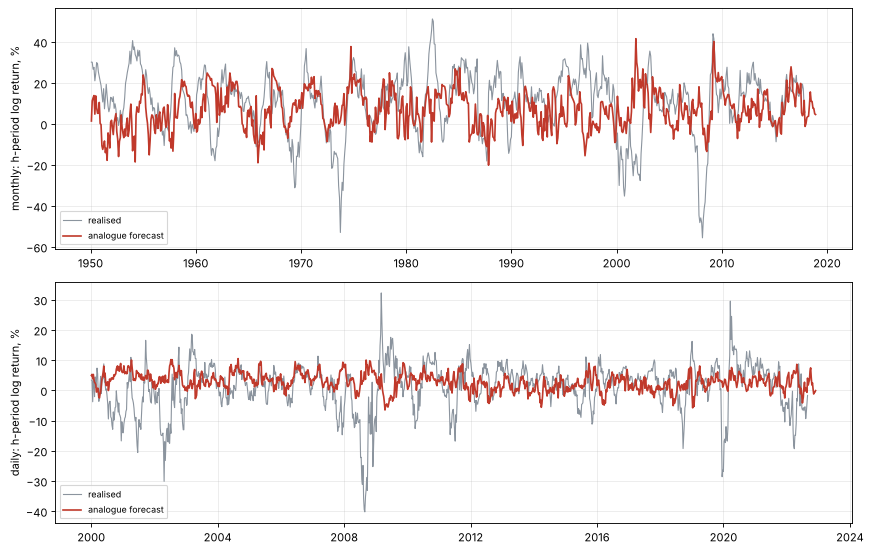

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
for ax, tag in zip(axes, ("monthly", "daily")):
    dt_, fc, y = out[tag + "_series"]
    ax.plot(dt_, y * 100, color=GREY, lw=1, label="realised")
    ax.plot(dt_, fc * 100, color=RED, lw=1.5, label="analogue forecast")
    ax.set_ylabel(f"{tag}: h-period log return, %"); ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

> 💡 **In plain words.** The forecast (red) wanders around a few percent; reality (grey) swings
> by tens of percent and pays it no attention. Note the raw sign hit rate looks respectable only
> because it roughly equals the share of up periods — a forecast that is "mostly positive" in a
> market that mostly rises. Against the drift, the hit rate is a coin.

## 5 · The full sweep — 126 combinations, all reported

126 combinations; raw one-sided p<0.05: 5 (4.0%); min Holm p 1.00; two-sided Holm survivors: 1


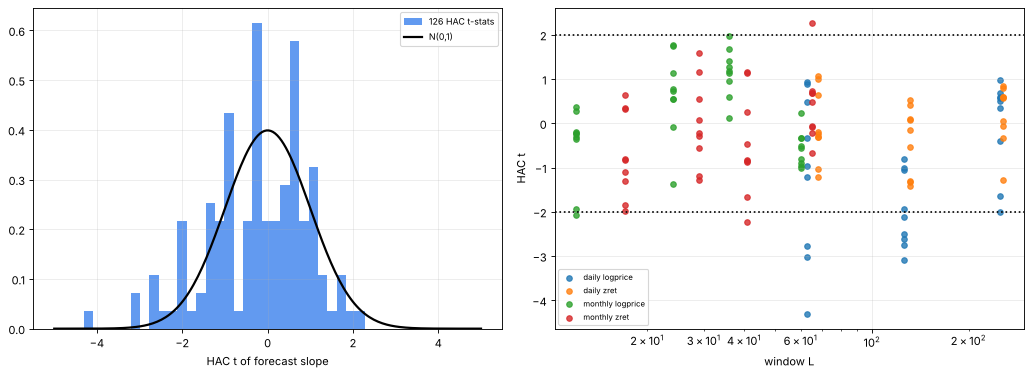

In [10]:
sm = st.sweep(m, st.GRID_MONTHLY, 12, "1950-01-31", step=1)
sd = st.sweep(d, st.GRID_DAILY, 252, "2000-01-03", step=5)
tm, td = sm["table"].assign(tape="monthly"), sd["table"].assign(tape="daily")
allt = pd.concat([tm, td], ignore_index=True)
allt["p_holm"] = st.holm(allt["p"].to_numpy())
allt["p_two"] = 2 * np.minimum(allt["p"], 1 - allt["p"])
allt["p_holm_two"] = st.holm(allt["p_two"].to_numpy())
print(f"{len(allt)} combinations; raw one-sided p<0.05: {(allt['p'] < 0.05).sum()} "
      f"({(allt['p'] < 0.05).mean():.1%}); min Holm p {allt['p_holm'].min():.2f}; "
      f"two-sided Holm survivors: {(allt['p_holm_two'] < 0.05).sum()}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
xs = np.linspace(-5, 5, 200)
axes[0].hist(allt["t"], bins=30, density=True, color=BLUE, alpha=0.7, label="126 HAC t-stats")
axes[0].plot(xs, np.exp(-xs ** 2 / 2) / np.sqrt(2 * np.pi), color="k", lw=2, label="N(0,1)")
axes[0].set_xlabel("HAC t of forecast slope"); axes[0].legend(fontsize=8)
for (tape, metric), g in allt.groupby(["tape", "metric"]):
    axes[1].scatter(g["L"] + (5 if metric == "zret" else 0), g["t"], s=25,
                    label=f"{tape} {metric}", alpha=0.8)
axes[1].axhline(2, color="k", ls=":"); axes[1].axhline(-2, color="k", ls=":")
axes[1].set_xscale("log"); axes[1].set_xlabel("window L"); axes[1].set_ylabel("HAC t")
axes[1].legend(fontsize=7); plt.tight_layout(); plt.show()

In [11]:
cols = ["tape", "metric", "L", "h", "k", "corr", "t", "p", "p_holm", "hit", "oos_r2",
        "sharpe_net", "sharpe_bh", "alpha_t", "time_in_market"]
print(allt[cols].sort_values("t", ascending=False).round(3).to_string(index=False))

   tape   metric   L  h  k    corr       t      p  p_holm    hit  oos_r2  sharpe_net  sharpe_bh  alpha_t  time_in_market
monthly     zret  60  1  1  0.0770  2.2780 0.0110  1.0000 0.5280 -1.7970      0.3170     0.5210  -0.8640          0.6160
monthly logprice  36  6  5  0.1230  1.9820 0.0240  1.0000 0.5210 -0.3960      0.5020     0.5210   1.3950          0.5640
monthly logprice  24 12  5  0.1320  1.7720 0.0380  1.0000 0.5570 -0.2160      0.4670     0.5210   0.2640          0.7610
monthly logprice  24  6  5  0.1210  1.7540 0.0400  1.0000 0.5210 -0.1530      0.4780     0.5210   0.4690          0.7590
monthly logprice  36  6  1  0.0990  1.6690 0.0480  1.0000 0.5150 -1.7920      0.4920     0.5210   1.0530          0.6590
monthly     zret  24  1  1  0.0600  1.5880 0.0560  1.0000 0.5070 -1.7820      0.2990     0.5210  -1.4890          0.6280
monthly logprice  36  1  1  0.0580  1.3980 0.0810  1.0000 0.5150 -2.1380      0.3110     0.5210  -0.8420          0.5870
monthly logprice  36 12  5  0.08

> 💡 **In plain words.** The 126 t-statistics look like a draw from a standard normal — what
> you would see if nothing were there — with a few long tails, and the longest one points the
> wrong way.

## 6 · The timing rule and the Reality Check

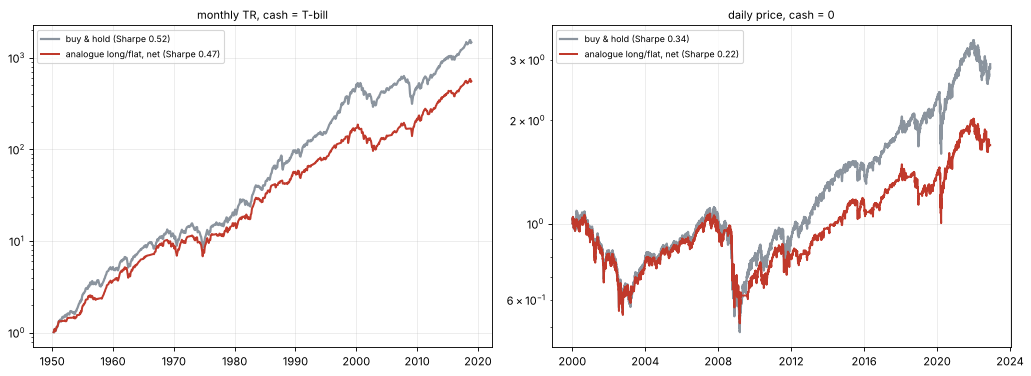

rules beating B&H on net Sharpe: monthly 2/72, daily 0/54


Reality Check, return race: monthly p 1.000 (best zret|L12|h12|k10), daily 1.000
Reality Check, vol-matched Sharpe race: monthly p 0.993 (best zret|L12|h12|k10), daily 1.000


,monthly,daily
sharpe_gross,0.4842,0.2444
sharpe_net,0.4670,0.2167
sharpe_bh,0.5210,0.3352
alpha_ann,0.0024,-0.0189
alpha_t,0.2644,-1.6931
time_in_market,0.7612,0.8536
turnover_per_year,2.1236,5.2026
max_dd,-0.4860,-0.5205
max_dd_bh,-0.5039,-0.5678


In [12]:
km = st.timing_rule(m, idx_m, out["monthly_series"][1], 12)
kd = st.timing_rule(d, idx_d, out["daily_series"][1], 252)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, r, ttl in ((axes[0], km, "monthly TR, cash = T-bill"),
                   (axes[1], kd, "daily price, cash = 0")):
    ax.plot(r["equity_bh"], color=GREY, lw=2, label=f"buy & hold (Sharpe {r['sharpe_bh']:.2f})")
    ax.plot(r["equity"], color=RED, lw=1.8,
            label=f"analogue long/flat, net (Sharpe {r['sharpe_net']:.2f})")
    ax.set_yscale("log"); ax.set_title(ttl, fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
rc_m = st.reality_check(sm["diffs"], 12, n_boot=300)
rc_d = st.reality_check(sd["diffs"], 252, n_boot=300)
print(f"rules beating B&H on net Sharpe: monthly {(tm['sharpe_net'] > tm['sharpe_bh']).sum()}/"
      f"{len(tm)}, daily {(td['sharpe_net'] > td['sharpe_bh']).sum()}/{len(td)}")
rv_m = st.reality_check(sm["diffs_vm"], 12, n_boot=300)
rv_d = st.reality_check(sd["diffs_vm"], 252, n_boot=300)
print(f"Reality Check, return race: monthly p {rc_m['reality_check_pvalue']:.3f} "
      f"(best {rc_m['best_rule']}), daily {rc_d['reality_check_pvalue']:.3f}")
print(f"Reality Check, vol-matched Sharpe race: monthly p {rv_m['reality_check_pvalue']:.3f} "
      f"(best {rv_m['best_rule']}), daily {rv_d['reality_check_pvalue']:.3f}")
pd.DataFrame({"monthly": {k: km[k] for k in ("sharpe_gross", "sharpe_net", "sharpe_bh",
                                            "alpha_ann", "alpha_t", "time_in_market",
                                            "turnover_per_year", "max_dd", "max_dd_bh")},
              "daily": {k: kd[k] for k in ("sharpe_gross", "sharpe_net", "sharpe_bh",
                                          "alpha_ann", "alpha_t", "time_in_market",
                                          "turnover_per_year", "max_dd", "max_dd_bh")}})

**Timing, exactly:** the forecast made at the close of period `t` is executed at the close of
`t + 1` and first earns period `t + 2`; costs 10 bp one-way × traded NAV; both legs' Sharpe
ratios are in excess of cash. The Reality Check is run as a *return race* (rule minus
buy-and-hold) and as a *Sharpe race* (each rule first scaled to buy-and-hold's volatility, so
de-risking gets credit); here with 300 resamples for speed, 1,000 in `docs/results.md`.

> 💡 **In plain words.** The rule mostly sits in the market anyway, steps out at random moments,
> and pays for the privilege. The best of every variant tried still does not beat doing nothing.

## 7 · The wrong-way lead

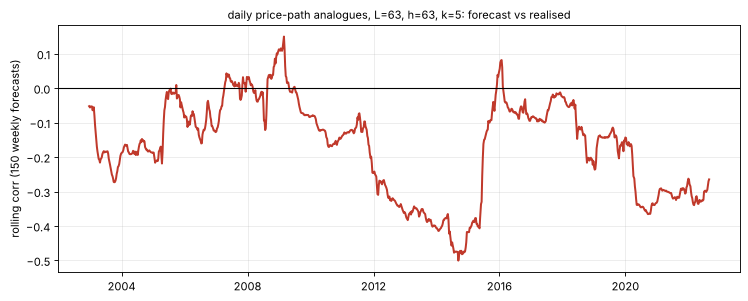

In [13]:
lp = d["logp"].to_numpy()
s_ = st.analogue_search(lp, 63, idx_d, k_max=5, gap=63)
fc = st.analogue_forecast(lp, s_, 63, 5); y = st.realised_forward(lp, idx_d, 63)
ok = np.isfinite(y)
roll = pd.Series(fc[ok], index=d.index[idx_d][ok]).rolling(150).corr(
    pd.Series(y[ok], index=d.index[idx_d][ok]))
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(roll, color=RED, lw=1.8); ax.axhline(0, color="k", lw=1)
ax.set_ylabel("rolling corr (150 weekly forecasts)")
ax.set_title("daily price-path analogues, L=63, h=63, k=5: forecast vs realised", fontsize=10)
plt.show()

The most extreme number in the grid (daily price path, L=63, h=63, k=5, t −4.31, two-sided Holm p
0.002) says the short-window daily analogues **anti-forecast** the next quarter.
It is robust to the lag choice, present in both halves and not the trailing return in disguise
(`docs/results.md` §7) — but it is one corner of a searched grid, absent from the monthly tape,
and a contrarian rule built on it after seeing the sign does not beat buy-and-hold net of costs.
Recorded as a lead for fresh data, not a finding.

## 8 · Power: the detector on a template that truly recurs (SYNTHETIC)

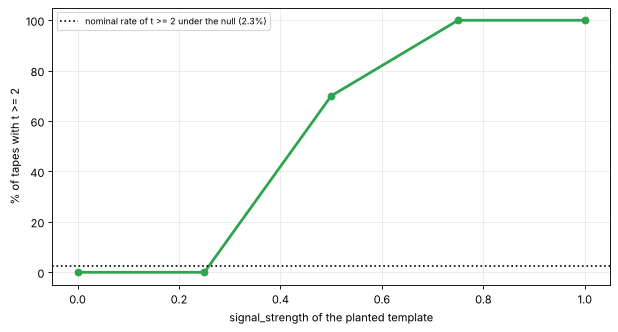

,reject (t>=2),median t,median best match
signal_strength,,,
0.0000,0.0000,0.5093,0.9058
0.2500,0.0000,0.5860,0.9024
0.5000,0.7000,2.8951,0.9143
0.7500,1.0000,5.3740,0.9263
1.0000,1.0000,7.8118,0.9371


In [14]:
rows = []
for sstr in (0.0, 0.25, 0.5, 0.75, 1.0):
    res = st.null_sweep_power(
        lambda sd_, s=sstr: data.synthetic_tape(n_periods=len(m), signal_strength=s,
                                                mu=mm["mu"], sigma=mm["sigma"], seed=sd_)[0],
        None, 12, "1950-01-31", range(1015, 1025), st.HEADLINE_MONTHLY)
    rows.append({"signal_strength": sstr, "reject (t>=2)": (res["t"] >= 2).mean(),
                 "median t": res["t"].median(), "median best match": res["match_corr_median"].median()})
pw = pd.DataFrame(rows).set_index("signal_strength")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(pw.index, pw["reject (t>=2)"] * 100, "o-", color=GREEN, lw=2.5)
ax.axhline(2.3, color="k", ls=":", label="nominal rate of t >= 2 under the null (2.3%)")
ax.set_xlabel("signal_strength of the planted template"); ax.set_ylabel("% of tapes with t >= 2")
ax.legend(fontsize=8); plt.show()
pw

> 💡 **In plain words.** With nothing planted the test stays quiet even though the best matches
> still look superb (~0.90). With the template planted at half strength or more, it fires. The
> machine can see a repeating pattern — the real market just does not have one.

## 9 · Could you trade it?

No. There is no forecasting signal to scale, and the costless gross Sharpe of the headline rules
already trails buy-and-hold, so capacity and impact never come into it. Execution would be
trivial (index futures or an ETF, a handful of switches a year); the problem is upstream.

## 10 · Going further

- **Other distances.** Dynamic time warping or Euclidean distance on scaled paths change the
  similarity score, not the null: any shape-matching on trending paths inherits §3.1.
- **Other templates.** 1987 and 2000 are inside the monthly tape and already part of the general
  search; a dedicated template test would mirror §3.4.
- **The reversal lead.** §3.4 (returns after big rallies) and §7 (daily anti-forecasting) both
  point at mean reversion, a separate claim with a separate literature (Fama & French 1988;
  Poterba & Summers 1988) and a strong dependence on the 1930s and on sample choice.
- **Fork the null.** `strategy.null_search_distribution`, `vol_path_walks` and
  `block_bootstrap_walks` calibrate any "today looks like X" chart in a few lines.